# IND320 - Part 2: Data sources

This notebook builds on the reservoir analysis from Part 1. The NVE section reads observations directly from the API. The electricity transfer section retrieves ENTSO-E data and processes it through Spark, Cassandra and MongoDB.

- [GitHub repository](https://github.com/Sipan2/IND320-Sipan2)
- [Streamlit app](https://ind320-sipan2.streamlit.app/)
- [NVE API documentation](https://biapi.nve.no/magasinstatistikk/swagger/index.html)

The notebook documents the analysis and database processing. The Streamlit app provides interactive views of the reservoir and electricity transfer data.

## 1. Reservoir data from NVE

The API replaces the local CSV file used in Part 1. Because the source is updated, later runs may return additional observations.

In [1]:
import json
from datetime import datetime, timezone
from urllib.request import urlopen
import pandas as pd

# NVE provides public reservoir observations as JSON.
url = "https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk/HentOffentligData"
with urlopen(url, timeout=60) as response:
    observations = json.load(response)

retrieved_at = datetime.now(timezone.utc)
print("Retrieved at (UTC):", retrieved_at.isoformat(timespec="seconds"))
reservoirs = pd.DataFrame(observations)
reservoirs.head()

Retrieved at (UTC): 2026-10-08T12:31:02+00:00


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 2. Check dates, areas and measurements

Each series is identified by both its area type and area number. The checks below show the date range, the number of observations per area and any duplicate records. The observation date is kept separate from the publication date.

In [2]:
# Check dates and use both area fields to identify each series.
reservoirs["dato_Id"] = pd.to_datetime(reservoirs["dato_Id"])
reservoirs = reservoirs.sort_values(["omrType", "omrnr", "dato_Id"])
print("Rows:", len(reservoirs))
print("Dates:", reservoirs["dato_Id"].min().date(), "to", reservoirs["dato_Id"].max().date())
print("Duplicate area/date rows:", reservoirs.duplicated(["omrType", "omrnr", "dato_Id"]).sum())
reservoirs.groupby(["omrType", "omrnr"]).size().rename("observations").to_frame()

Rows: 14913
Dates: 1995-01-08 to 2026-10-04
Duplicate area/date rows: 0


observations
omrType omrnr              
EL      1              1657
        2              1657
        3              1657
        4              1657
        5              1657
NO      0              1657
VASS    1              1657
        2              1657
        3              1657

### English column names and national series

NO 0 is the national series. We keep the observation date on the horizontal axis and do not use the next publication date as a measurement date.

In [3]:
# Rename the API fields and select the national observations.
column_names = {
    "dato_Id": "date", "omrType": "area_type", "omrnr": "area_number",
    "iso_aar": "iso_year", "iso_uke": "iso_week",
    "fyllingsgrad": "filling_ratio", "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_ratio",
    "endring_fyllingsgrad": "weekly_filling_ratio_change",
}
data = reservoirs.rename(columns=column_names)
national = data.loc[(data.area_type == "NO") & (data.area_number == 0)].set_index("date")
measurements = ["filling_ratio", "capacity_twh", "stored_energy_twh",
                "previous_week_filling_ratio", "weekly_filling_ratio_change"]
national[measurements].head()

,filling_ratio,capacity_twh,stored_energy_twh,previous_week_filling_ratio,weekly_filling_ratio_change
date,,,,,
1995-01-08,0.607988,87.43758,53.161003,0.752631,-0.144643
1995-01-15,0.582088,87.43758,50.896374,0.607988,-0.025900
1995-01-22,0.562121,87.43758,49.150486,0.582088,-0.019967
1995-01-29,0.534222,87.43758,46.711033,0.562121,-0.027899
1995-02-05,0.506221,87.43758,44.262720,0.534222,-0.028001


### Missing values and week numbers

These checks help distinguish missing measurements from gaps in a series. The ISO year and week are compared with the observation date, rather than assuming the calendar year is always the ISO year. The next publication date is metadata and is not used to place observations on the time axis.

In [4]:
# Check all areas before choosing a series for plotting.
quality = data[measurements].agg(["count", "min", "max"]).T
quality["missing"] = data[measurements].isna().sum()
display(quality)

# Compare the supplied ISO fields with the actual observation dates.
iso_dates = data["date"].dt.isocalendar()
week_mismatch = (data["iso_year"] != iso_dates["year"]) | (data["iso_week"] != iso_dates["week"])
print("Rows with different ISO year/week:", int(week_mismatch.sum()))

# Show gaps without filling or inventing observations.
gaps = data.groupby(["area_type", "area_number"])["date"].diff().dt.days
print("Intervals other than seven days:", int((gaps.notna() & gaps.ne(7)).sum()))
print("Publication dates beginning with year 0001:",
      int(data["next_publication_date"].astype(str).str.startswith("0001").sum()))

,count,min,max,missing
filling_ratio,14913.0,0.051653,1.020072,0
capacity_twh,14913.0,6.003264,87.437580,0
stored_energy_twh,14913.0,0.310089,84.518060,0
previous_week_filling_ratio,14913.0,0.051653,1.020037,0
weekly_filling_ratio_change,14913.0,-0.242484,0.345632,0


Rows with different ISO year/week: 0
Intervals other than seven days: 0
Publication dates beginning with year 0001: 11322


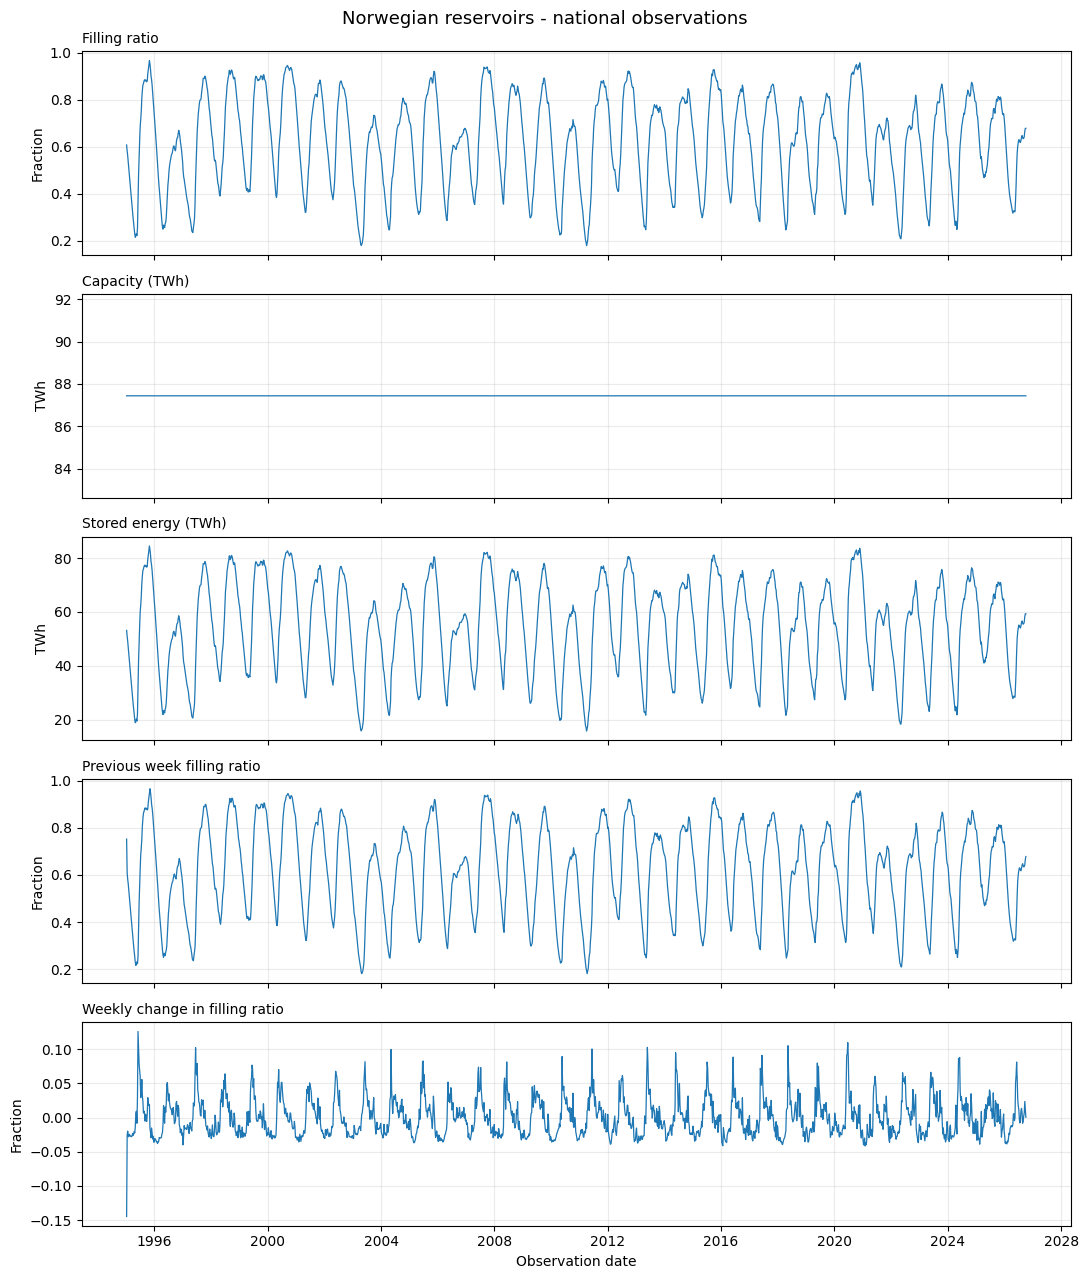

In [5]:
import matplotlib.pyplot as plt

# Separate axes preserve the original units of each measurement.
labels = ["Filling ratio", "Capacity (TWh)", "Stored energy (TWh)",
          "Previous week filling ratio", "Weekly change in filling ratio"]
fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True)
for ax, column, label in zip(axes, measurements, labels):
    ax.plot(national.index, national[column], linewidth=0.9)
    ax.set_title(label, loc="left", fontsize=10)
    ax.set_ylabel("TWh" if column.endswith("twh") else "Fraction")
    ax.grid(alpha=0.25)
fig.suptitle("Norwegian reservoirs - national observations", fontsize=13)
axes[-1].set_xlabel("Observation date")
fig.tight_layout()
plt.show()

### Comparing changes on one scale

Min-max scaling maps each changing series to 0-1. Constant series have no range, so they are left out of this comparison and listed below. Their original values are still shown in the separate plots.

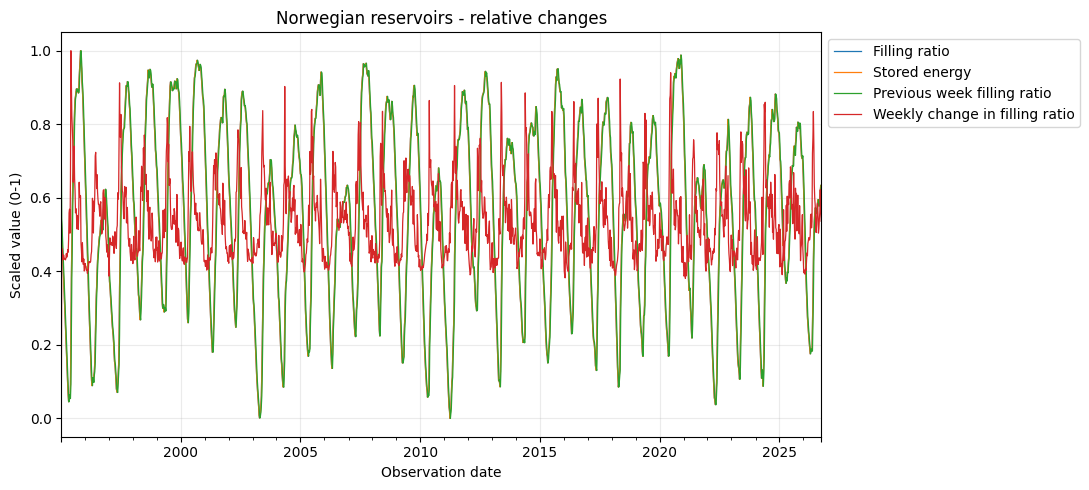

Constant measurements omitted: ['capacity_twh']


In [6]:
# Avoid division by zero for measurements that stay constant.
values = national[measurements]
span = values.max() - values.min()
changing = span[span > 0].index
constant = span[span == 0].index.tolist()
scaled = (values[changing] - values[changing].min()) / span[changing]
ax = scaled.rename(columns=dict(zip(measurements, [label.replace(" (TWh)", "") for label in labels]))).plot(figsize=(11, 5), linewidth=0.9)
ax.set_title("Norwegian reservoirs - relative changes")
ax.set_xlabel("Observation date")
ax.set_ylabel("Scaled value (0-1)")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
print("Constant measurements omitted:", constant)

The scaled lines can overlap, so this figure is best read alongside the separate plots. Scaling removes the original units: a value of 1 means the largest observed value for that series, not a full reservoir. Constant capacity remains visible in the separate plot.

## 3. Electricity transfers from ENTSO-E

The period is 1 October 2024 to 1 October 2026 (exclusive end), the last 24 complete months when this analysis was prepared. Requests use Norwegian calendar boundaries converted to UTC. This gives one complete calendar year, 2025, for the annual comparison. The 2024 and 2026 totals cover only part of those years.

The nine connections are NO1-SE3, NO2-DK1, NO2-NL, NO2-DE-LU, NO2-GB, NO3-SE2, NO4-SE1, NO4-SE2 and NO4-FI. Each is requested in both directions. Internal connections between Norwegian areas are excluded.

`download_entsoe.py` retrieves physical flows (document type A11) in monthly requests and keeps the original XML locally. The API token is entered privately and is not saved in this notebook or GitHub. Run that script before this section if the XML files are not already present.

Power is reported in MW. Energy in MWh equals power multiplied by interval duration in hours. A03 curves hold each value until the next reported position or the end of the period. A01 curves describe individual intervals, so an absent position stays missing. The parser checks the direction, unit, positions and overlapping records.

Source: [ENTSO-E explanation of A01 and A03 curves](https://transparencyplatform.zendesk.com/hc/en-us/articles/30262342482961-CurveType-A01-vs-CurveType-A03).


In [7]:
from pathlib import Path
import sys

# Locate the helper modules whether Jupyter starts in the project or notebooks folder.
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from prepare_transfers import prepare

# Validate every response before combining the intervals for Spark.
interval_file, coverage_rows = prepare()
coverage = pd.DataFrame(coverage_rows)
coverage["coverage_percent"] = 100 * coverage["observed_hours"] / coverage["expected_hours"]
display(coverage.groupby(["connection", "direction"])[["observed_hours", "expected_hours"]].sum())
incomplete = coverage.loc[coverage["observed_hours"] < coverage["expected_hours"]]
print("Months with incomplete coverage:", len(incomplete))
if not incomplete.empty:
    display(incomplete)


Prepared 1025076 intervals.
Months with incomplete coverage: 0


observed_hours  expected_hours
connection  direction                                
NO1 - SE3   export            17520.0         17520.0
            import            17520.0         17520.0
NO2 - DE-LU export            17520.0         17520.0
            import            17520.0         17520.0
NO2 - DK1   export            17520.0         17520.0
            import            17520.0         17520.0
NO2 - GB    export            17520.0         17520.0
            import            17520.0         17520.0
NO2 - NL    export            17520.0         17520.0
            import            17520.0         17520.0
NO3 - SE2   export            17520.0         17520.0
            import            17520.0         17520.0
NO4 - FI    export            17520.0         17520.0
            import            17520.0         17520.0
NO4 - SE1   export            17520.0         17520.0
            import            17520.0         17520.0
NO4 - SE2   export            17520.0         17520.0
            import            17520.0         17520.0

Months with incomplete coverage: 0


## 4. Spark and Cassandra

Cassandra runs locally in Docker. Start it from the project folder with `docker compose -p part2 up -d`. The database port is bound to this computer only. The environment uses Python 3.12, Java 17, Spark 3.5.1 and the matching Cassandra connector.

The function below writes the validated intervals through Spark, reads selected fields back from Cassandra and checks the row count. The table key contains connection, direction, month and interval start, so rerunning the same download does not create duplicate rows.

Spark then groups observations into UTC hours. It sums energy and observed duration, and calculates average power from these two quantities. Missing intervals are not filled with zero. The original resolution and curve type remain in Cassandra; MongoDB needs only the hourly fields used by the app.


In [8]:
from transfer_pipeline import build_curated

# This executes the real Spark -> Cassandra -> Spark path, including read-back checks.
pipeline_result = build_curated()
print("Validated database processing:", pipeline_result)


Prepared 1025076 intervals.
Months with incomplete coverage: 0


:: loading settings :: url = jar:file:/private/tmp/ind320-runtime/lib/python3.12/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /Users/sipan/Documents/IND320/part2/project/.ivy2/cache
The jars for the packages stored in: /Users/sipan/Documents/IND320/part2/project/.ivy2/jars
com.datastax.spark#spark-cassandra-connector_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-2dd9bcbc-7026-48ea-b14a-e94a34fa7a8f;1.0
	confs: [default]


	found com.datastax.spark#spark-cassandra-connector_2.12;3.5.1 in central


	found com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.1 in central


...

	found com.thoughtworks.paranamer#paranamer;2.8 in central


	found org.scala-lang#scala-reflect;2.12.19 in central
:: resolution report :: resolve 22553ms :: artifacts dl 9ms
	:: modules in use:
	com.datastax.oss#java-driver-shaded-guava;25.1-jre-graal-sub-1 from central in [default]
	com.datastax.oss#native-protocol;1.5.1 from central in [default]
	com.datastax.spark#spark-cassandra-connector-driver_2.12;3.5.1 from central in [default]
	com.datastax.spark#spark-cassandra-connector_2.12;3.5.1 from central in [default]
	com.thoughtworks.paranamer#paranamer;2.8 from central in [default]
	com.typesafe#config;1.4.1 from central in [default]
	io.dropwizard.metrics#metrics-core;4.1.18 from central in [default]
	org.apache.cassandra#java-driver-core-shaded;4.18.1 from central in [default]
	org.apache.cassandra#java-driver-mapper-runtime;4.18.1 from central in [default]
	org.apache.cassandra#java-driver-query-builder;4.18.1 from central in [default]
	org.apache.commons#commons-lang3;3.10 from central in [default]
	org.hdrhistogram#HdrHistogram;2.1.12 f

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


{'raw_intervals': 1025076, 'curated_hours': 315360, 'incomplete_months': 0}


Validated database processing: {'raw_intervals': 1025076, 'curated_hours': 315360, 'incomplete_months': 0}


## 5. Imports and exports

The following figures use the hourly data extracted from Cassandra by Spark. Import and export are always defined from Norway's perspective. I use NO2-DK1 and the complete calendar year 2025 for the examples. These are physical cross-border flows, not electricity production.


In [9]:
# Read the local output of the Spark extraction, not the original API files.
transfers = pd.read_json(project_root / "entsoe_raw" / "curated.jsonl", lines=True)
transfers["start_utc"] = pd.to_datetime(transfers["start_utc"], utc=True)
transfers["end_utc"] = pd.to_datetime(transfers["end_utc"], utc=True)
transfers["local_time"] = transfers["start_utc"].dt.tz_convert("Europe/Oslo")
connection, year = "NO2 - DK1", 2025
annual = transfers.loc[transfers["connection"].eq(connection) & transfers["local_time"].dt.year.eq(year)]
print("Hourly rows in the complete dataset:", len(transfers))
display(annual.head())


Hourly rows in the complete dataset: 315360


,connection,direction,start_utc,energy_mwh,observed_hours,power_mw,end_utc,local_time
72289,NO2 - DK1,export,2024-12-31 23:00:00+00:00,0.0,1,0.0,2025-01-01 00:00:00+00:00,2025-01-01 00:00:00+01:00
72290,NO2 - DK1,export,2025-01-01 00:00:00+00:00,0.0,1,0.0,2025-01-01 01:00:00+00:00,2025-01-01 01:00:00+01:00
72291,NO2 - DK1,export,2025-01-01 01:00:00+00:00,0.0,1,0.0,2025-01-01 02:00:00+00:00,2025-01-01 02:00:00+01:00
72292,NO2 - DK1,export,2025-01-01 02:00:00+00:00,0.0,1,0.0,2025-01-01 03:00:00+00:00,2025-01-01 03:00:00+01:00
72293,NO2 - DK1,export,2025-01-01 03:00:00+00:00,0.0,1,0.0,2025-01-01 04:00:00+00:00,2025-01-01 04:00:00+01:00


Observed hours by direction: {'import': 8760, 'export': 8760}
Expected hours in 2025: 8760


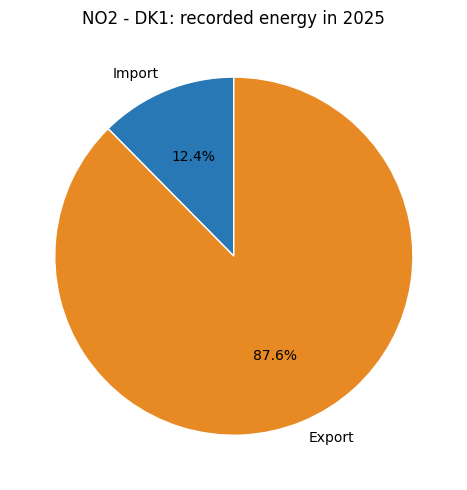

,Energy (GWh)
direction,
import,1153.915030
export,8157.330695


In [10]:
# Sum energy, rather than summing power values with different interval lengths.
totals = annual.groupby("direction")["energy_mwh"].sum().reindex(["import", "export"], fill_value=0)
observed = annual.groupby("direction")["observed_hours"].sum().reindex(["import", "export"], fill_value=0)
print("Observed hours by direction:", observed.to_dict())
print("Expected hours in 2025:", 8760)
fig, ax = plt.subplots(figsize=(7, 5))
if totals.sum() > 0:
    ax.pie(totals, labels=["Import", "Export"], autopct="%1.1f%%", startangle=90,
           colors=["#2878b5", "#e88a24"], wedgeprops={"edgecolor": "white"})
ax.set_title(f"{connection}: recorded energy in {year}")
fig.tight_layout()
plt.show()
display((totals / 1000).rename("Energy (GWh)").to_frame())
if (observed < 8760).any():
    print("Coverage is incomplete: these are recorded totals, not estimates for missing hours.")


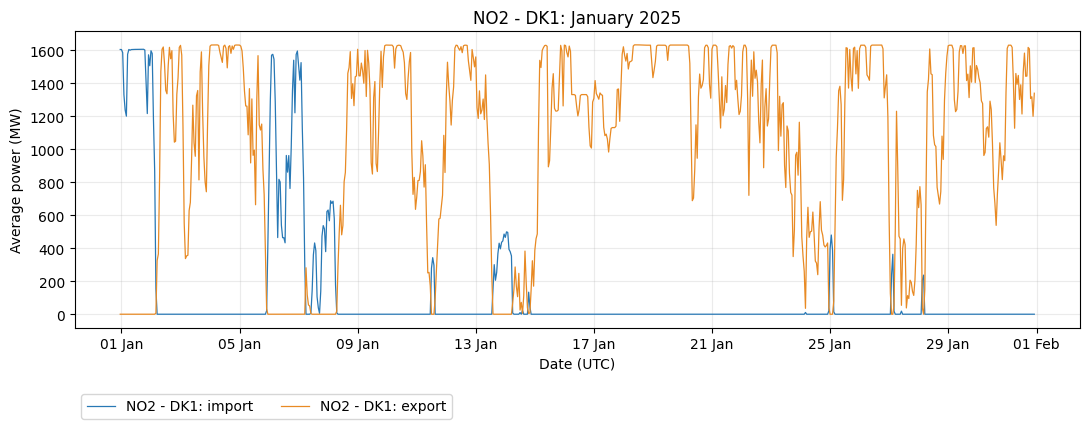

In [11]:
import matplotlib.dates as mdates
from datetime import timezone

# Select January in Norwegian time; show UTC explicitly on the horizontal axis.
month_start = pd.Timestamp("2025-01-01", tz="Europe/Oslo").tz_convert("UTC")
month_end = pd.Timestamp("2025-02-01", tz="Europe/Oslo").tz_convert("UTC")
hours = pd.date_range(month_start, month_end, freq="h", inclusive="left")
fig, ax = plt.subplots(figsize=(11, 4.5))
for direction, colour in [("import", "#2878b5"), ("export", "#e88a24")]:
    series = annual.loc[annual["direction"].eq(direction)].set_index("start_utc")["power_mw"]
    # Reindexing leaves NaN gaps where no hourly observation was published.
    series = series.reindex(hours)
    ax.plot(hours, series, label=f"{connection}: {direction}", color=colour, linewidth=0.9)
ax.set(title="NO2 - DK1: January 2025", xlabel="Date (UTC)", ylabel="Average power (MW)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b", tz=timezone.utc))
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=2)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()


## 6. MongoDB and Streamlit

`upload_curated()` in `transfer_pipeline.py` uploads the Spark-extracted hourly records to `ind320.transfers`. The database password is entered privately. Each document has a stable identifier based on connection, direction and timestamp, allowing repeat uploads without duplicate documents. The upload checks the number of records read back from MongoDB.

The Streamlit app connects directly to MongoDB using a separate user with read access only. Credentials are stored in Streamlit Secrets. The left column offers connection and year controls for the pie chart. The right column lets the reader choose a month and flow directions. An expander describes the source and preparation.

The right-hand chart requirement in Canvas still says "Not updated yet" as of 8 October 2026. I interpret it as a monthly view of the requested transfer data and use import/export selections rather than production groups. This point should be checked again before submission.


In [12]:
# The upload writes this confirmation only after the MongoDB read-back check passes.
# It contains a record count, never credentials.
with (project_root / "entsoe_raw" / "mongodb_result.json").open() as source:
    mongo_result = json.load(source)
print("Verified hourly observations in MongoDB:", mongo_result["verified_observations"])


Verified hourly observations in MongoDB: 315360


## 7. AI usage

I arranged the API access and set up the accounts and websites needed for Part 2. I wrote some of the code myself and used AI to help with other parts of the code, troubleshooting and explanations. AI also helped me put my own notes and reflections into English. The work therefore includes both my own contributions and AI assistance.

## 8. Work log

Part 2 builds on the reservoir app from Part 1, but the data now comes from APIs rather than a local CSV file. I arranged the API access and the accounts and websites needed for the project. I also wrote some of the code myself. AI helped with other parts of the implementation, troubleshooting and wording, as described in the AI section.

The first change was to connect the notebook and Streamlit app to NVE. The notebook checks dates, area identifiers and missing values before plotting the measurements. Keeping the observation date separate from the publication date matters here. The area type and area number also need to be used together, since a number alone does not identify a series. In the app, the area controls and interval slider make it possible to explore a smaller part of the data.

ENTSO-E required more setup because access had to be approved before a token could be generated. The download covers the last 24 complete months, from October 2024 to September 2026, for nine connections in both directions. The original responses are kept locally so they can be checked without repeating the download.

A key part of the processing is the difference between power and energy. Adding MW values directly would give misleading totals when measurement intervals differ. Instead, each value is multiplied by its interval length to calculate MWh. Compressed periods are expanded according to the API format, while missing observations remain missing.

The database work follows the sequence required in the assignment: Spark writes the intervals to Cassandra, reads the relevant fields back and prepares hourly records for MongoDB. Checks compare row counts, time coverage and energy totals. Streamlit then reads the prepared data using a separate database account with read access only.

The notebook shows the calculations and fixed examples, while the app lets the reader change the connection, year, month and direction. Partial years are labelled so their totals are not mistaken for complete years. The right-hand chart instructions in Canvas still need checking before submission because that section is marked as not updated yet.
